In [1]:
import os
import json
import warnings  # ← Добавить эту строку
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv

In [2]:
# Отключаем предупреждения о небезопасном соединении
warnings.filterwarnings('ignore')

# Настройка
load_dotenv()
DATE_BEGIN = os.getenv('DATE_BEGIN', '2023-03-01')
DATE_END = os.getenv('DATE_END', '2023-09-01')
API_URL = os.getenv('API_URL', 'https://data-charts-api.hexlet.app')

# Запрос с отключенной проверкой SSL
visits_response = requests.get(
    f'{API_URL}/visits', 
    params={'begin': DATE_BEGIN, 'end': DATE_END},
    verify=False,  # 🔧 Отключаем проверку сертификата
    timeout=30     # 🔧 Добавляем таймаут на случай зависания
)

visits_json = visits_response.json()
visits_df = pd.DataFrame(visits_json)
print(f"✅ Загружено {len(visits_df)} визитов")

✅ Загружено 263459 визитов


In [3]:
warnings.filterwarnings('ignore')  # Отключаем предупреждение о небезопасном соединении

# Загрузка сырых данных о регистрациях с API
regs_response = requests.get(
    f'{API_URL}/registrations', 
    params={'begin': DATE_BEGIN, 'end': DATE_END},
    verify=False,  # 🔧 Отключаем проверку сертификата
    timeout=30     # 🔧 Добавляем таймаут
)
regs_json = regs_response.json()
regs_df = pd.DataFrame(regs_json)
print(f"✅ Загружено {len(regs_df)} регистраций")

✅ Загружено 21836 регистраций


In [4]:
# Очистка визитов: удаление ботов и дубликатов, приведение дат к нужному формату.
visits_df['datetime'] = pd.to_datetime(visits_df['datetime']).dt.normalize()
visits_cleaned = visits_df[~visits_df['user_agent'].str.contains('bot', case=False, na=False)]
visits_cleaned = visits_cleaned.sort_values(['visit_id', 'datetime'])
visits_cleaned = visits_cleaned.groupby('visit_id', as_index=False).last()
visits_grouped = visits_cleaned.groupby(['datetime', 'platform'], as_index=False)['visit_id'].count()
visits_grouped = visits_grouped.rename(columns={'visit_id': 'visits', 'datetime': 'date_group'})

In [5]:
# Группировка регистраций по датам и платформам.
regs_df['datetime'] = pd.to_datetime(regs_df['datetime']).dt.normalize()
regs_grouped = regs_df.groupby(['datetime', 'platform'], as_index=False)['user_id'].agg('count')
regs_grouped = regs_grouped.rename(columns={'user_id': 'registrations', 'datetime': 'date_group'})

In [6]:
# Объединение визитов и регистраций в единую таблицу conversion_df (Merge).
conversion_df = pd.merge(
    visits_grouped, regs_grouped,
    left_on=['date_group', 'platform'],
    right_on=['date_group', 'platform'],
    how='outer'
)

In [7]:
# Техническая обработка: заполнение пропусков нулями и настройка типов данных.
conversion_df['date_group'] = conversion_df['date_group'].dt.date
conversion_df['visits'] = conversion_df['visits'].fillna(0).astype(int)
conversion_df['registrations'] = conversion_df['registrations'].fillna(0).astype(int)
conversion_df['conversion'] = (conversion_df['registrations'] / conversion_df['visits'] * 100)
conversion_df['conversion'] = conversion_df['conversion'].fillna(0)
conversion_df = conversion_df.sort_values(['date_group', 'platform']).reset_index(drop=True)
conversion_df.to_json('./conversion.json')

In [8]:
# Создание сводной таблицы conversion_daily
conversion_daily = conversion_df.groupby('date_group', as_index=False)[['visits', 'registrations']].sum()
conversion_daily['date_group'] = pd.to_datetime(conversion_daily['date_group'])

In [9]:
# Загрузка данных о рекламе из ads.csv и их группировка.
ads_df = pd.read_csv('./ads.csv')
ads_df['date_group'] = pd.to_datetime(ads_df['date'])
ads_grouped = ads_df.groupby(['date_group', 'utm_campaign'], as_index=False).agg({
    'cost': 'sum'
})

In [10]:
# # Объединяем таблицу визитов и регистраций с данными о расходах на рекламу
final_df = pd.merge(
    conversion_daily,
    ads_grouped,
    on='date_group',
    how='left'
)

In [11]:
# Финальное объединение: статистика визитов + данные о расходах на рекламу (final_df).
final_df['cost'] = final_df['cost'].fillna(0)
final_df['utm_campaign'] = final_df['utm_campaign'].fillna('none')
final_df = final_df.sort_values(['date_group', 'utm_campaign'])
final_df = final_df[['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']]
final_df.to_json('./ads.json', date_format='iso')

In [12]:
# Создаем папку charts
os.makedirs('./charts', exist_ok=True)

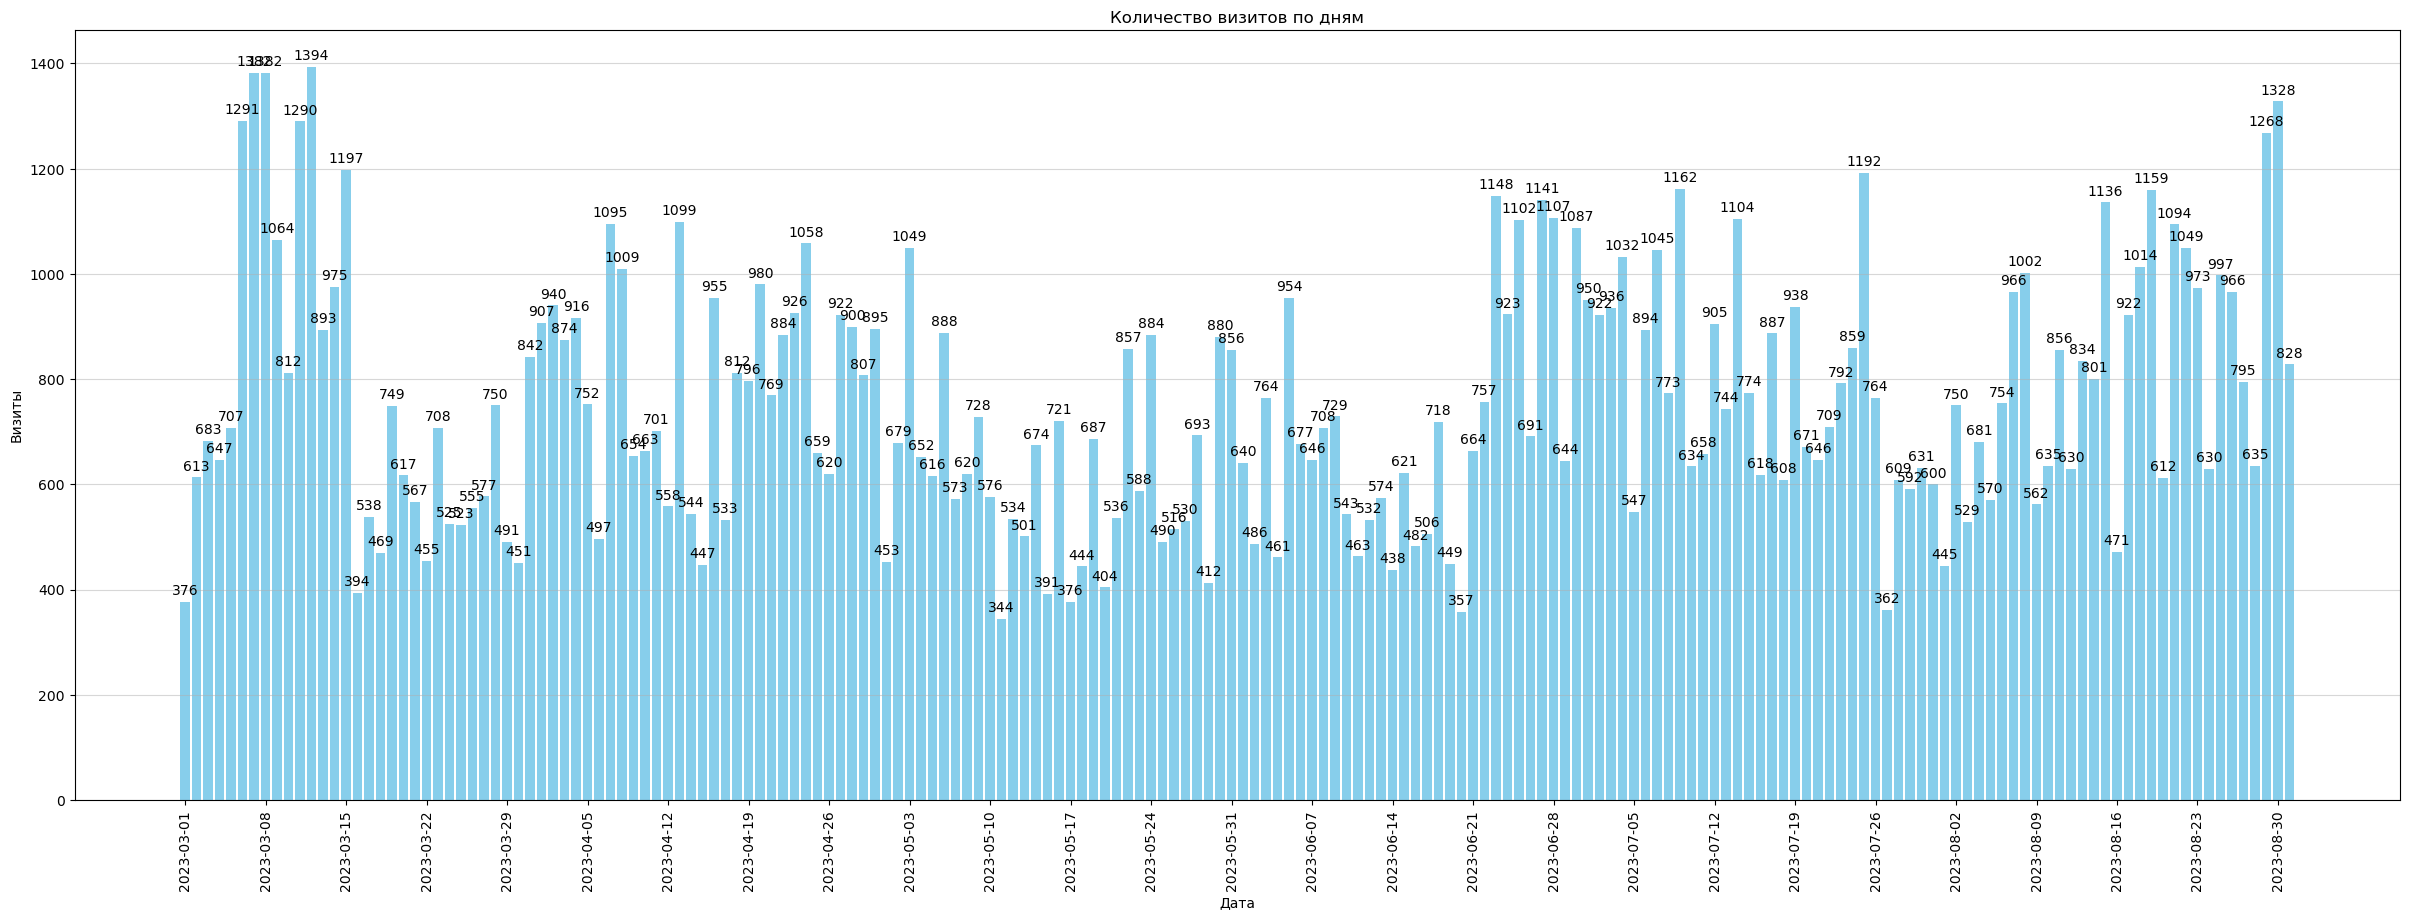

In [13]:
# Общее количество визитов по дням
plt.figure(figsize=(30, 10))
plt.title('Количество визитов по дням')
bars = plt.bar(conversion_daily['date_group'], conversion_daily['visits'], color='skyblue')
plt.xlabel("Дата")
plt.ylabel("Визиты")
plt.xticks(conversion_daily['date_group'][::7], rotation=90)
plt.grid(axis='y', alpha=0.5)
plt.bar_label(bars, padding=3, fontsize=10)
plt.savefig('./charts/Total_visits.png')
plt.show()

In [14]:
# Расчет % конверсии в общей таблице и разделение данных на 3 датафрейма: Android, iOS, Web.
conversion_df['conversion_rate'] = (conversion_df['registrations'] / conversion_df['visits']) * 100
conversion_df['date_group'] = pd.to_datetime(conversion_df['date_group'])
data_android = conversion_df[conversion_df['platform'] == 'android']
data_ios = conversion_df[conversion_df['platform'] == 'ios']
data_web = conversion_df[conversion_df['platform'] == 'web']

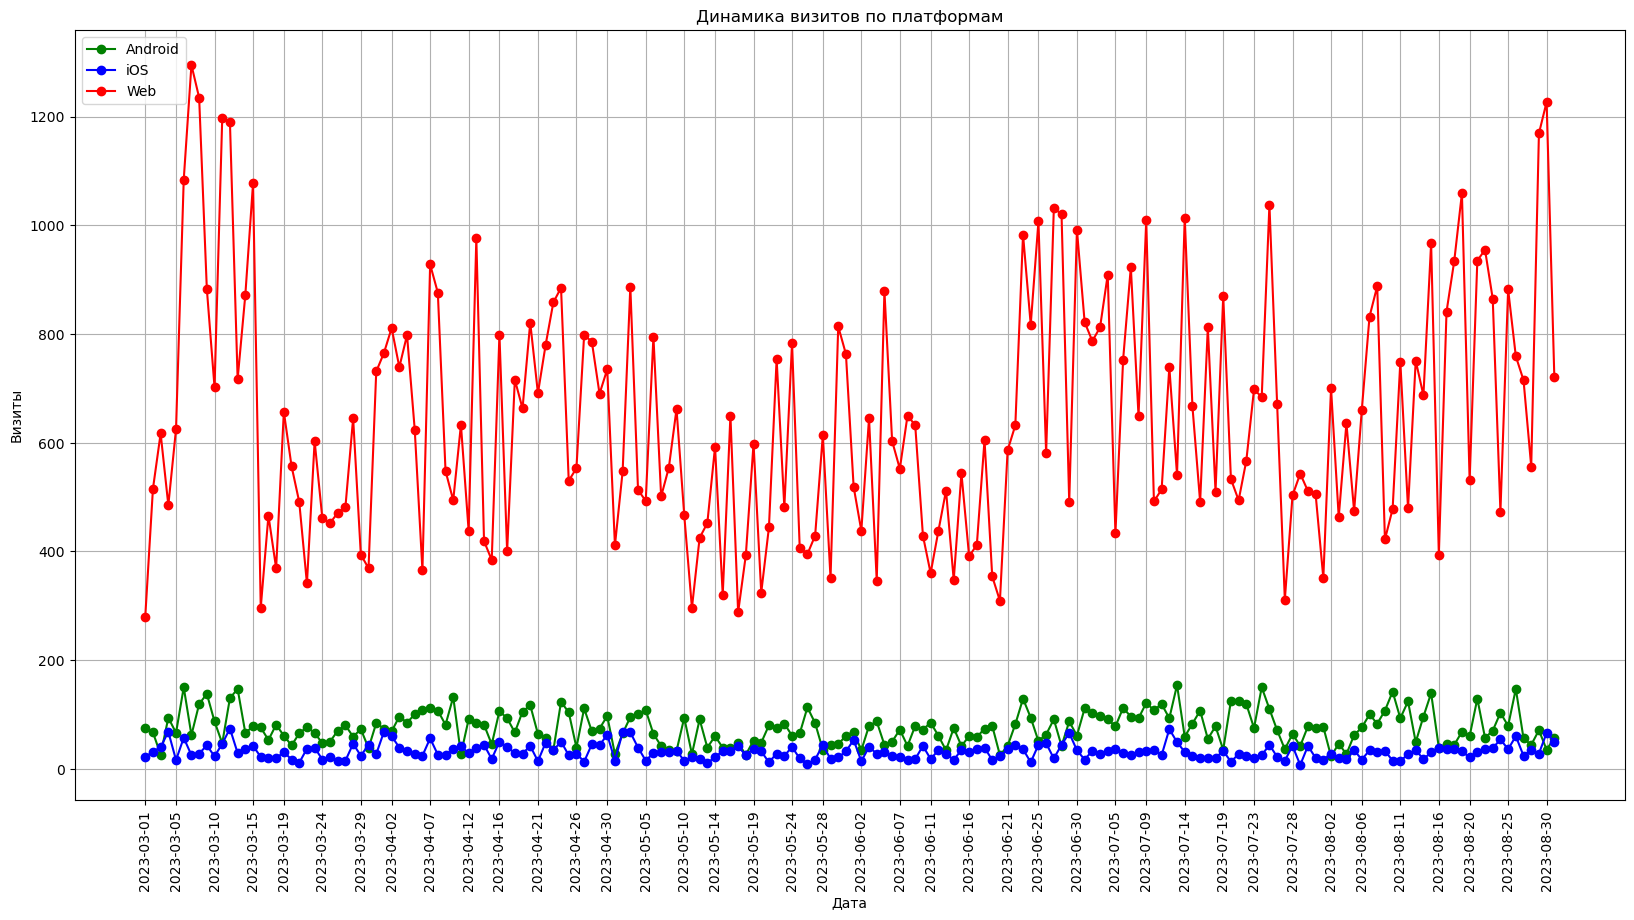

In [15]:
# Динамика визитов с разбивкой по трем платформам
plt.figure(figsize=(20, 10)) # Размер по вкусу
plt.plot(data_android['date_group'], data_android['visits'],
         label='Android', color='green', marker='o')
plt.plot(data_ios['date_group'], data_ios['visits'],
         label='iOS', color='blue', marker='o')
plt.plot(data_web['date_group'], data_web['visits'],
         label='Web', color='red', marker='o')
plt.title('Динамика визитов по платформам')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.grid(True)
plt.legend()
plt.xticks(conversion_df['date_group'][::14], rotation=90)
plt.savefig('./charts/visits_by_platform.png')
plt.show()

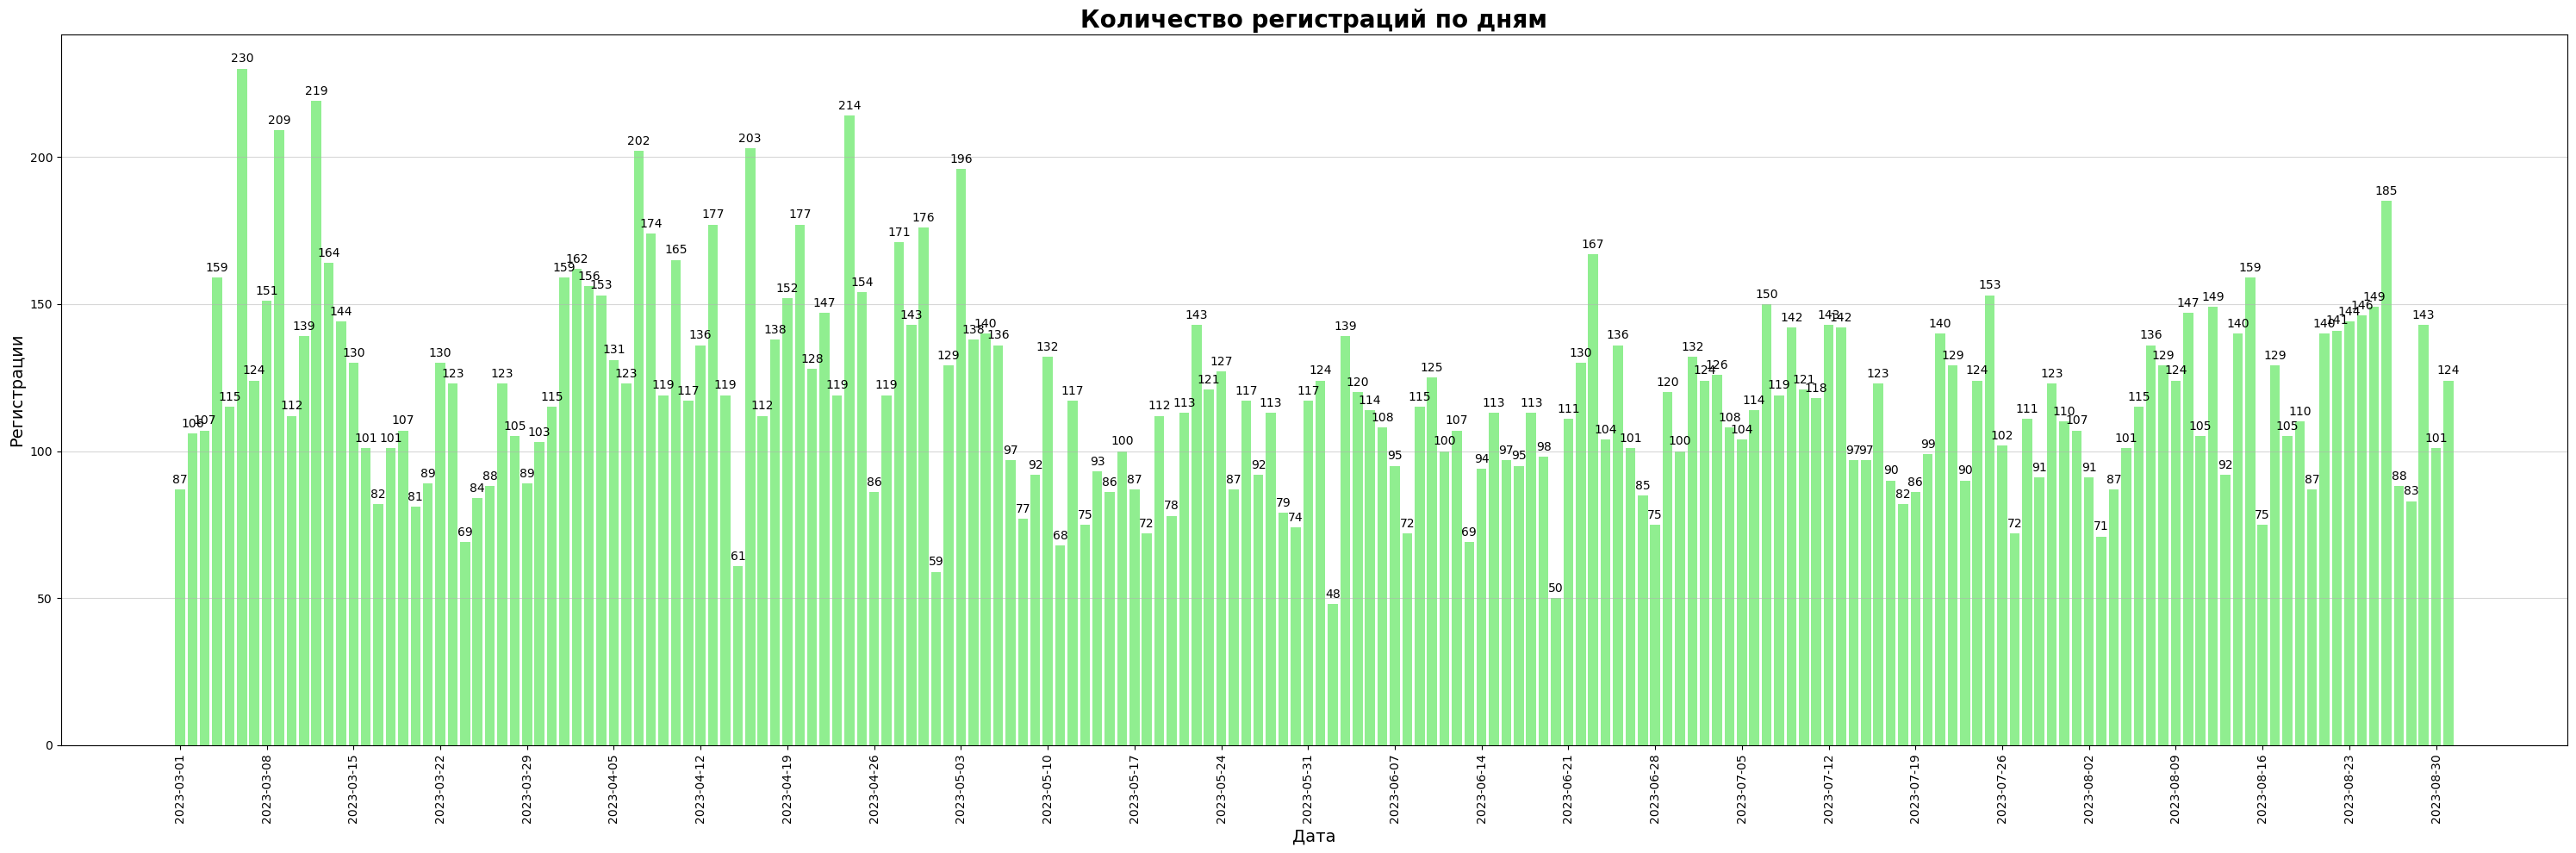

In [16]:
# Общее количество регистраций по дням.
plt.figure(figsize=(30, 10))
plt.title('Количество регистраций по дням', fontsize=20, fontweight='bold')
bars = plt.bar(conversion_daily['date_group'], conversion_daily['registrations'], color='lightgreen')
plt.xlabel("Дата", fontsize=14)
plt.ylabel("Регистрации", fontsize=14)
plt.xticks(conversion_daily['date_group'][::7], rotation=90)
plt.grid(axis='y', alpha=0.5)
plt.bar_label(bars, padding=3, fontsize=10)
plt.tight_layout()
plt.savefig('./charts/total_registrations.png')
plt.show()

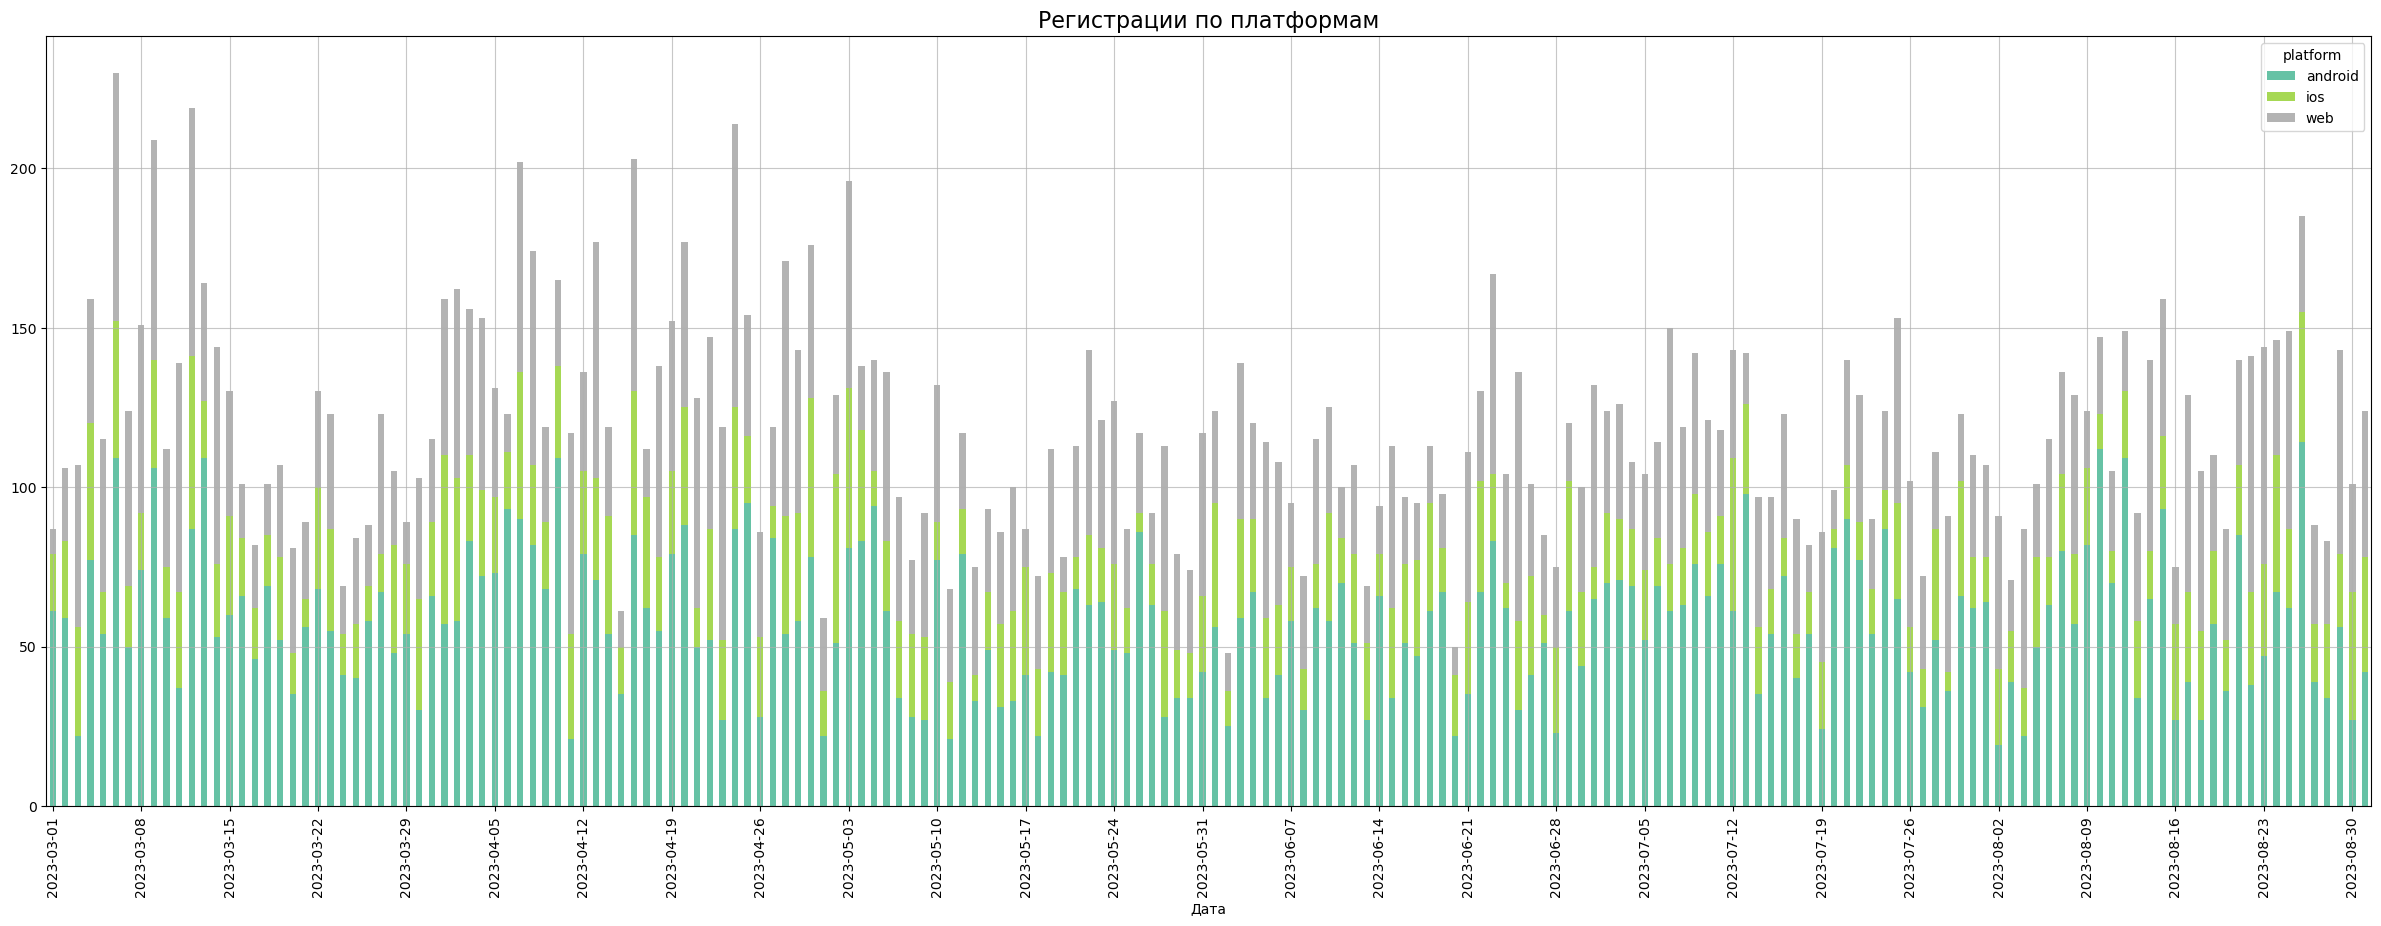

In [17]:
# Регистрации по платформам
pivot_reg = conversion_df.pivot_table(index='date_group',
                                      columns='platform',
                                      values='registrations',
                                      aggfunc='sum')
pivot_reg.index = pivot_reg.index.strftime('%Y-%m-%d')
pivot_reg.plot(kind='bar', stacked=True, figsize=(30, 10), colormap="Set2")

plt.title('Регистрации по платформам', fontsize=16)
plt.xlabel("Дата")
plt.xticks(ticks=range(0, len(pivot_reg), 7), labels=pivot_reg.index[::7], rotation=90)
plt.legend(title="platform", loc='upper right')
plt.grid(alpha=0.7)
plt.savefig('./charts/registrations_by_platform.png')
plt.show()

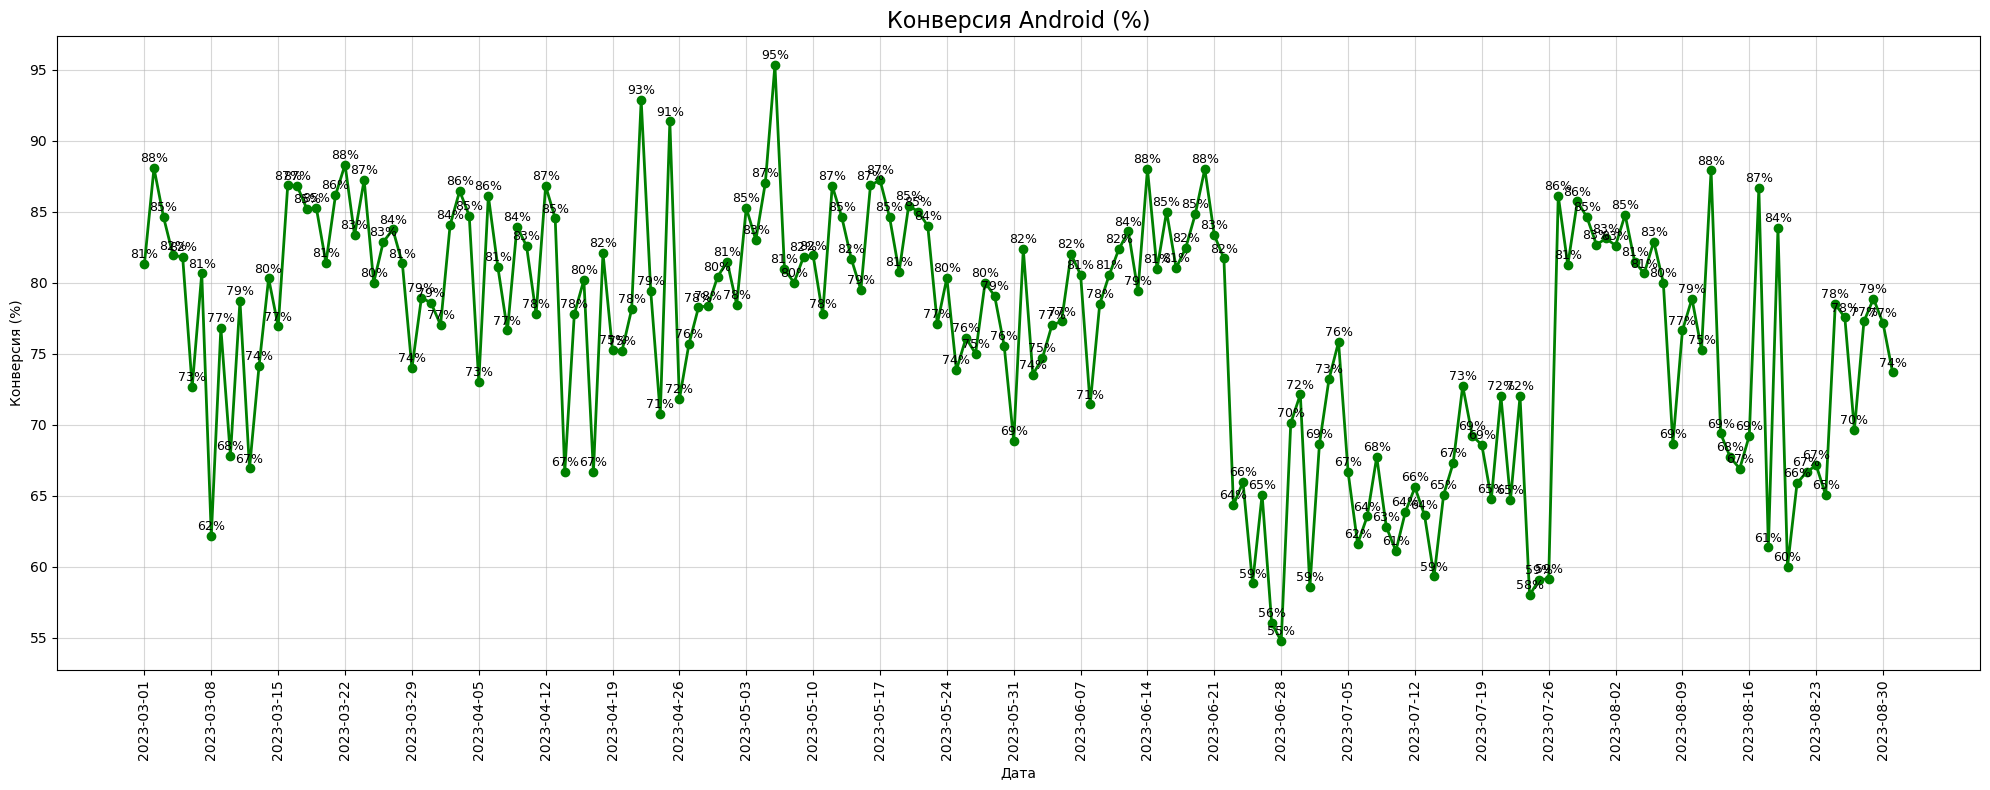

In [18]:
# Конверсия Android
plt.figure(figsize=(20, 8))
plt.title('Конверсия Android (%)', fontsize=16)
plt.plot(data_android['date_group'], data_android['conversion_rate'],
         marker='o', color='green', linewidth=2)
plt.xlabel('Дата')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.5)
plt.xticks(data_android['date_group'][::7], rotation=90)

for x, y in zip(data_android['date_group'], data_android['conversion_rate']):
    plt.text(x, y + 0.2, f"{y:.0f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('./charts/conversion_android.png')
plt.show()

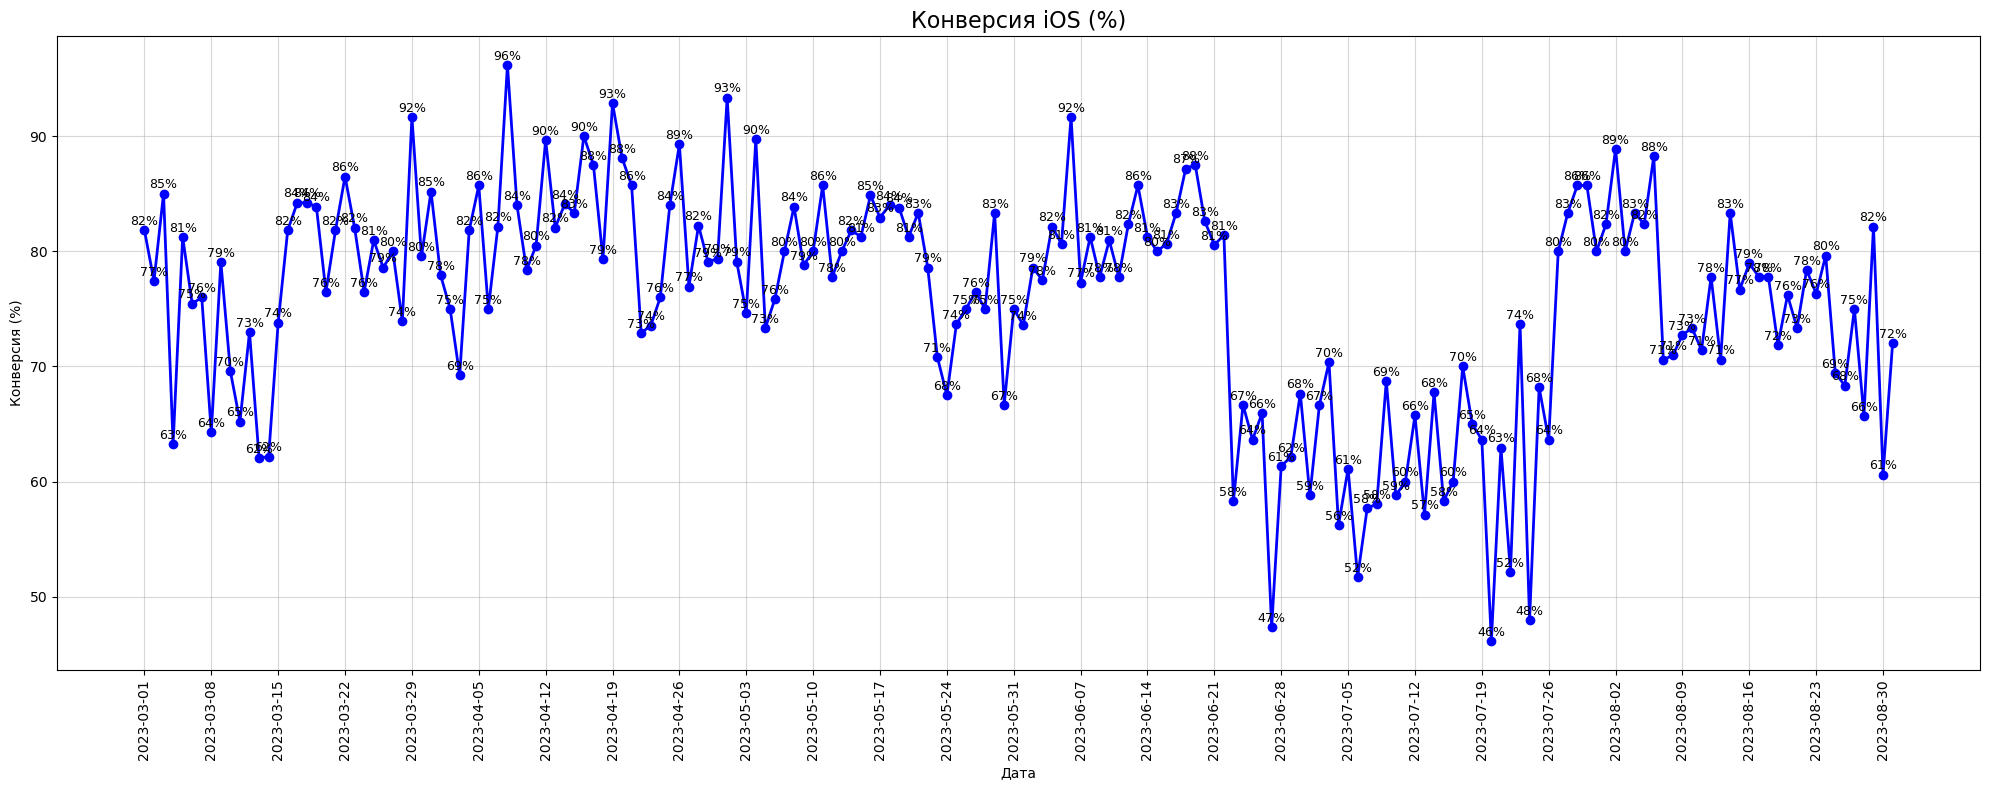

In [19]:
# Конверсия iOS
plt.figure(figsize=(20, 8))
plt.title('Конверсия iOS (%)', fontsize=16)
plt.plot(data_ios['date_group'], data_ios['conversion_rate'],
         marker='o', color='blue', linewidth=2)
plt.xlabel('Дата')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.5)
plt.xticks(data_ios['date_group'][::7], rotation=90)

for x, y in zip(data_ios['date_group'], data_ios['conversion_rate']):
    plt.text(x, y + 0.2, f"{y:.0f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('./charts/conversion_ios.png')
plt.show()

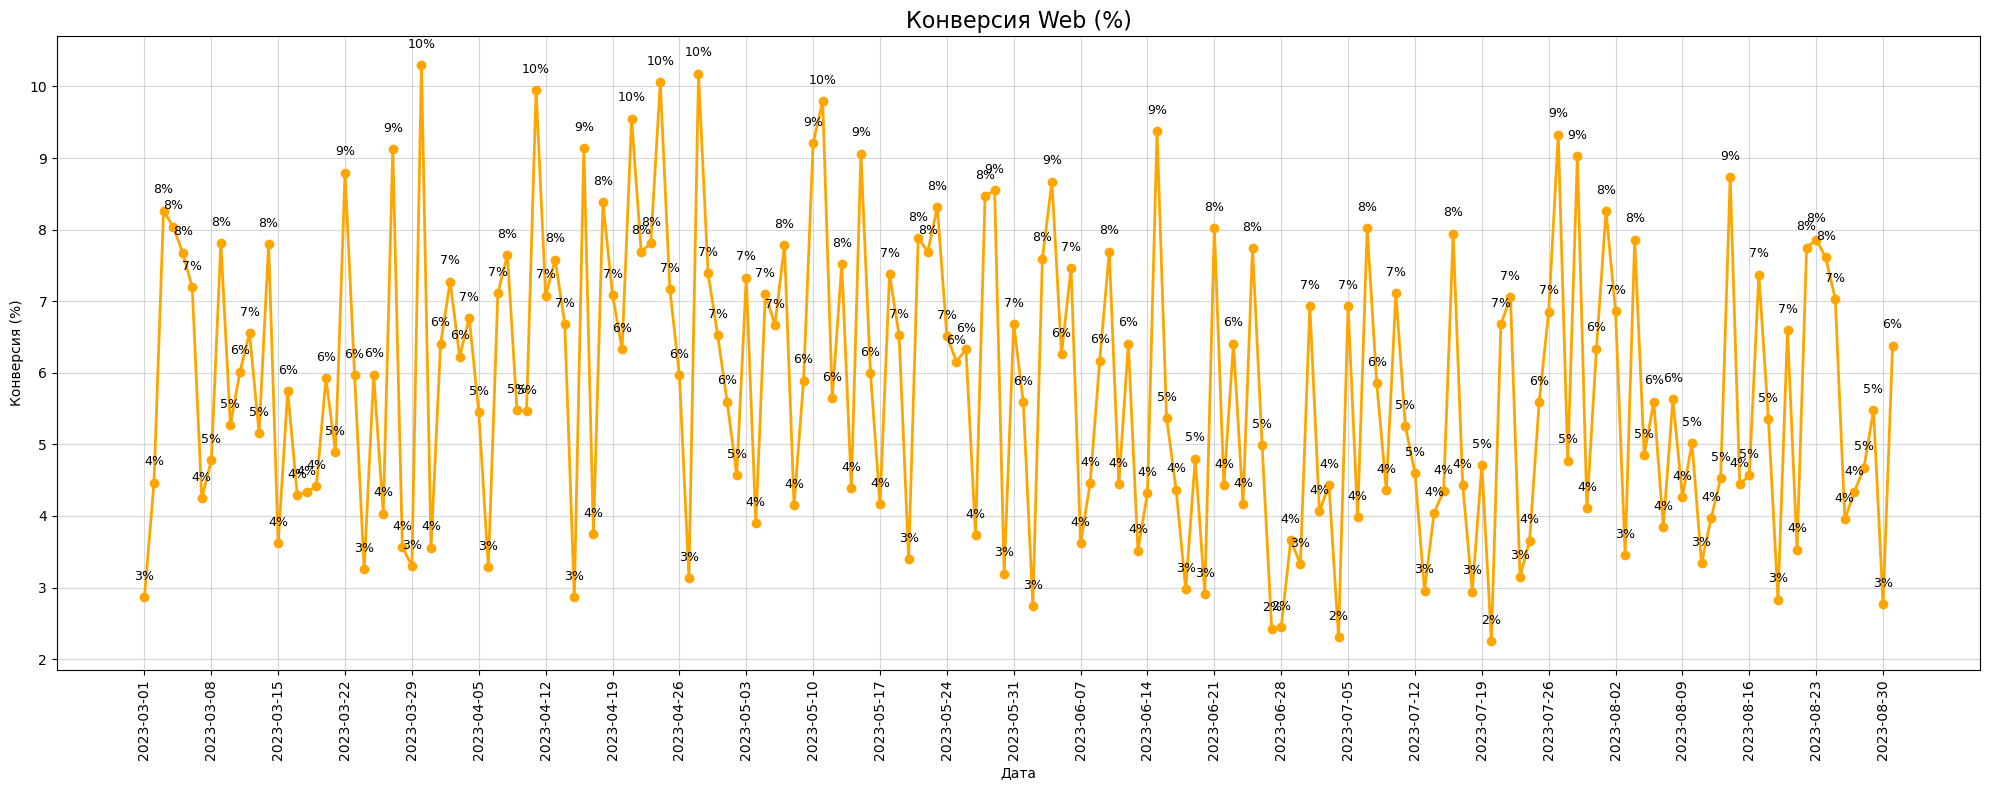

In [20]:
# Конверсия Web
plt.figure(figsize=(20, 8))
plt.title('Конверсия Web (%)', fontsize=16)
plt.plot(data_web['date_group'], data_web['conversion_rate'],
         marker='o', color='orange', linewidth=2)
plt.xlabel('Дата')
plt.ylabel('Конверсия (%)')
plt.grid(True, alpha=0.5)
plt.xticks(data_web['date_group'][::7], rotation=90)

for x, y in zip(data_web['date_group'], data_web['conversion_rate']):
    plt.text(x, y + 0.2, f"{y:.0f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./charts/conversion_web.png')
plt.show()

In [21]:
# Подготовка данных для расчета средней общей конверсии
avg_conv = conversion_df.groupby('date_group', as_index=False)[['visits', 'registrations']].sum()
avg_conv['conversion'] = (avg_conv['registrations'] / avg_conv['visits']) * 100
mean_val = avg_conv['conversion'].mean()

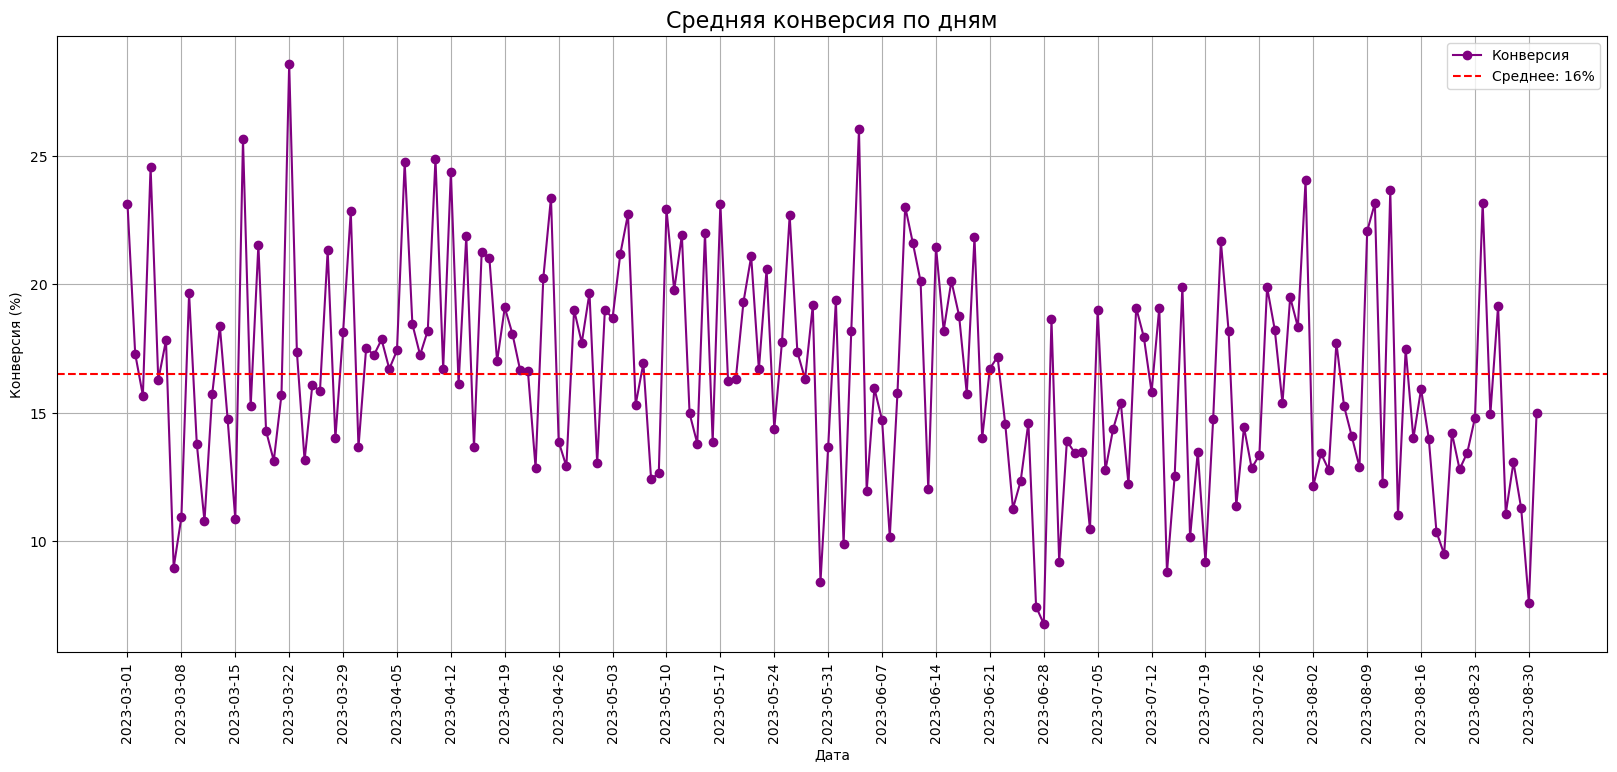

In [22]:
# Средняя конверсия по дням
plt.figure(figsize=(20, 8))
plt.title('Средняя конверсия по дням', fontsize=16)
plt.plot(avg_conv['date_group'], avg_conv['conversion'],
         marker='o', color='purple', label='Конверсия')
plt.axhline(y=mean_val, color='red', linestyle='--',
            label=f'Среднее: {mean_val:.0f}%')
plt.xlabel('Дата')
plt.ylabel('Конверсия (%)')
plt.grid()
plt.legend()
plt.xticks(avg_conv['date_group'][::7], rotation=90)

plt.savefig('./charts/average_conversion.png')
plt.show()

In [23]:
# Подготовка данных по затратам
cost_by_date = ads_df.groupby('date', as_index=False)['cost'].sum()
cost_by_date['date'] = pd.to_datetime(cost_by_date['date']).dt.strftime('%Y-%m-%d')

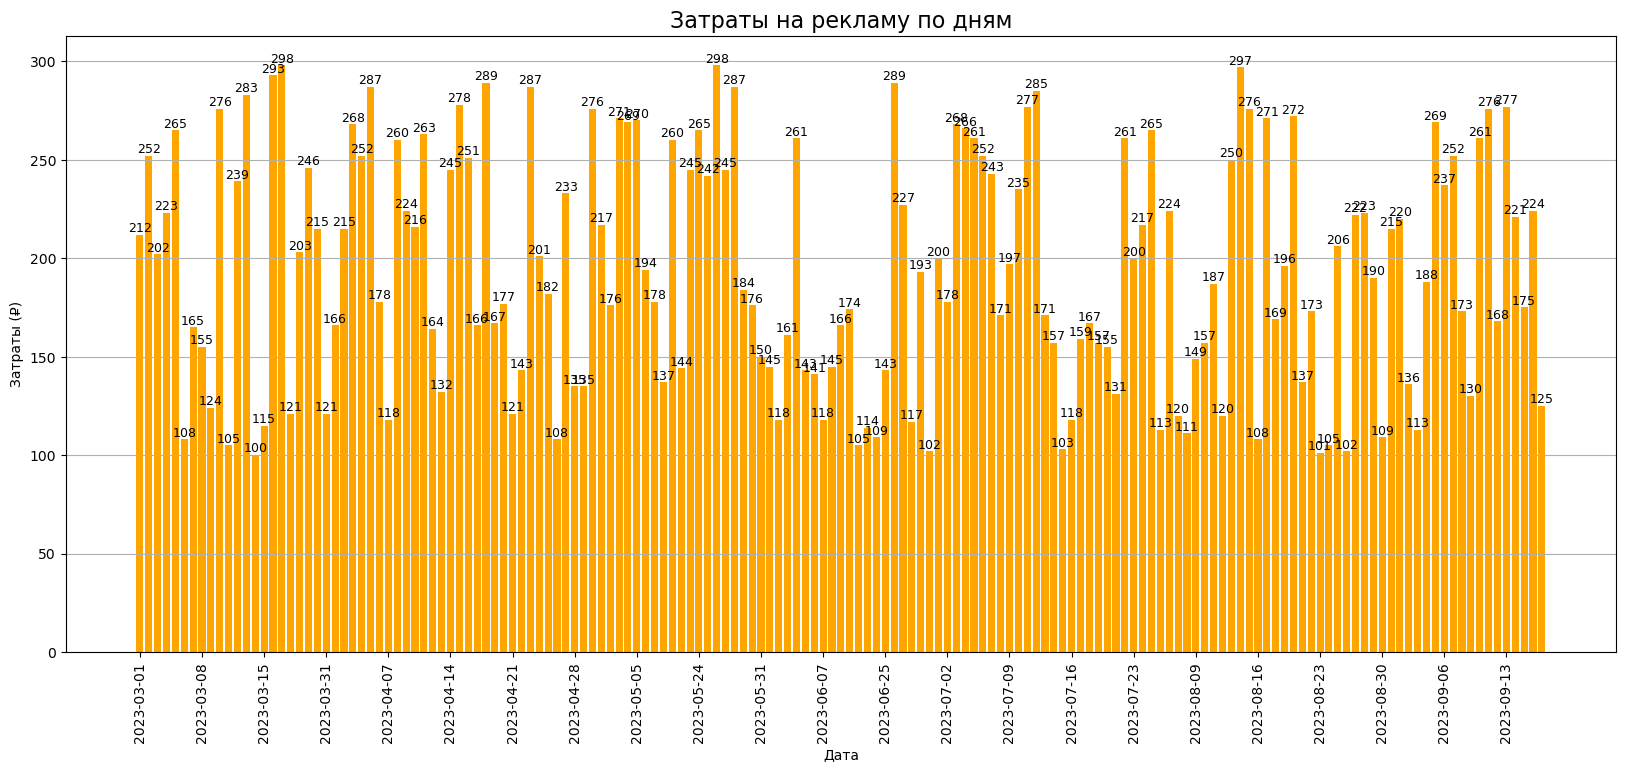

In [24]:
# Затраты на рекламу
plt.figure(figsize=(20, 8))
plt.title('Затраты на рекламу по дням', fontsize=16)
plt.bar(cost_by_date['date'], cost_by_date['cost'], color='orange')

for x, y in zip(cost_by_date['date'], cost_by_date['cost']):
    if y > 0:
        plt.text(x, y, f'{int(y)}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Дата')
plt.ylabel('Затраты (₽)')
plt.grid(axis='y')
plt.xticks(cost_by_date['date'][::7], rotation=90)
plt.savefig('./charts/ad_costs.png')
plt.show()

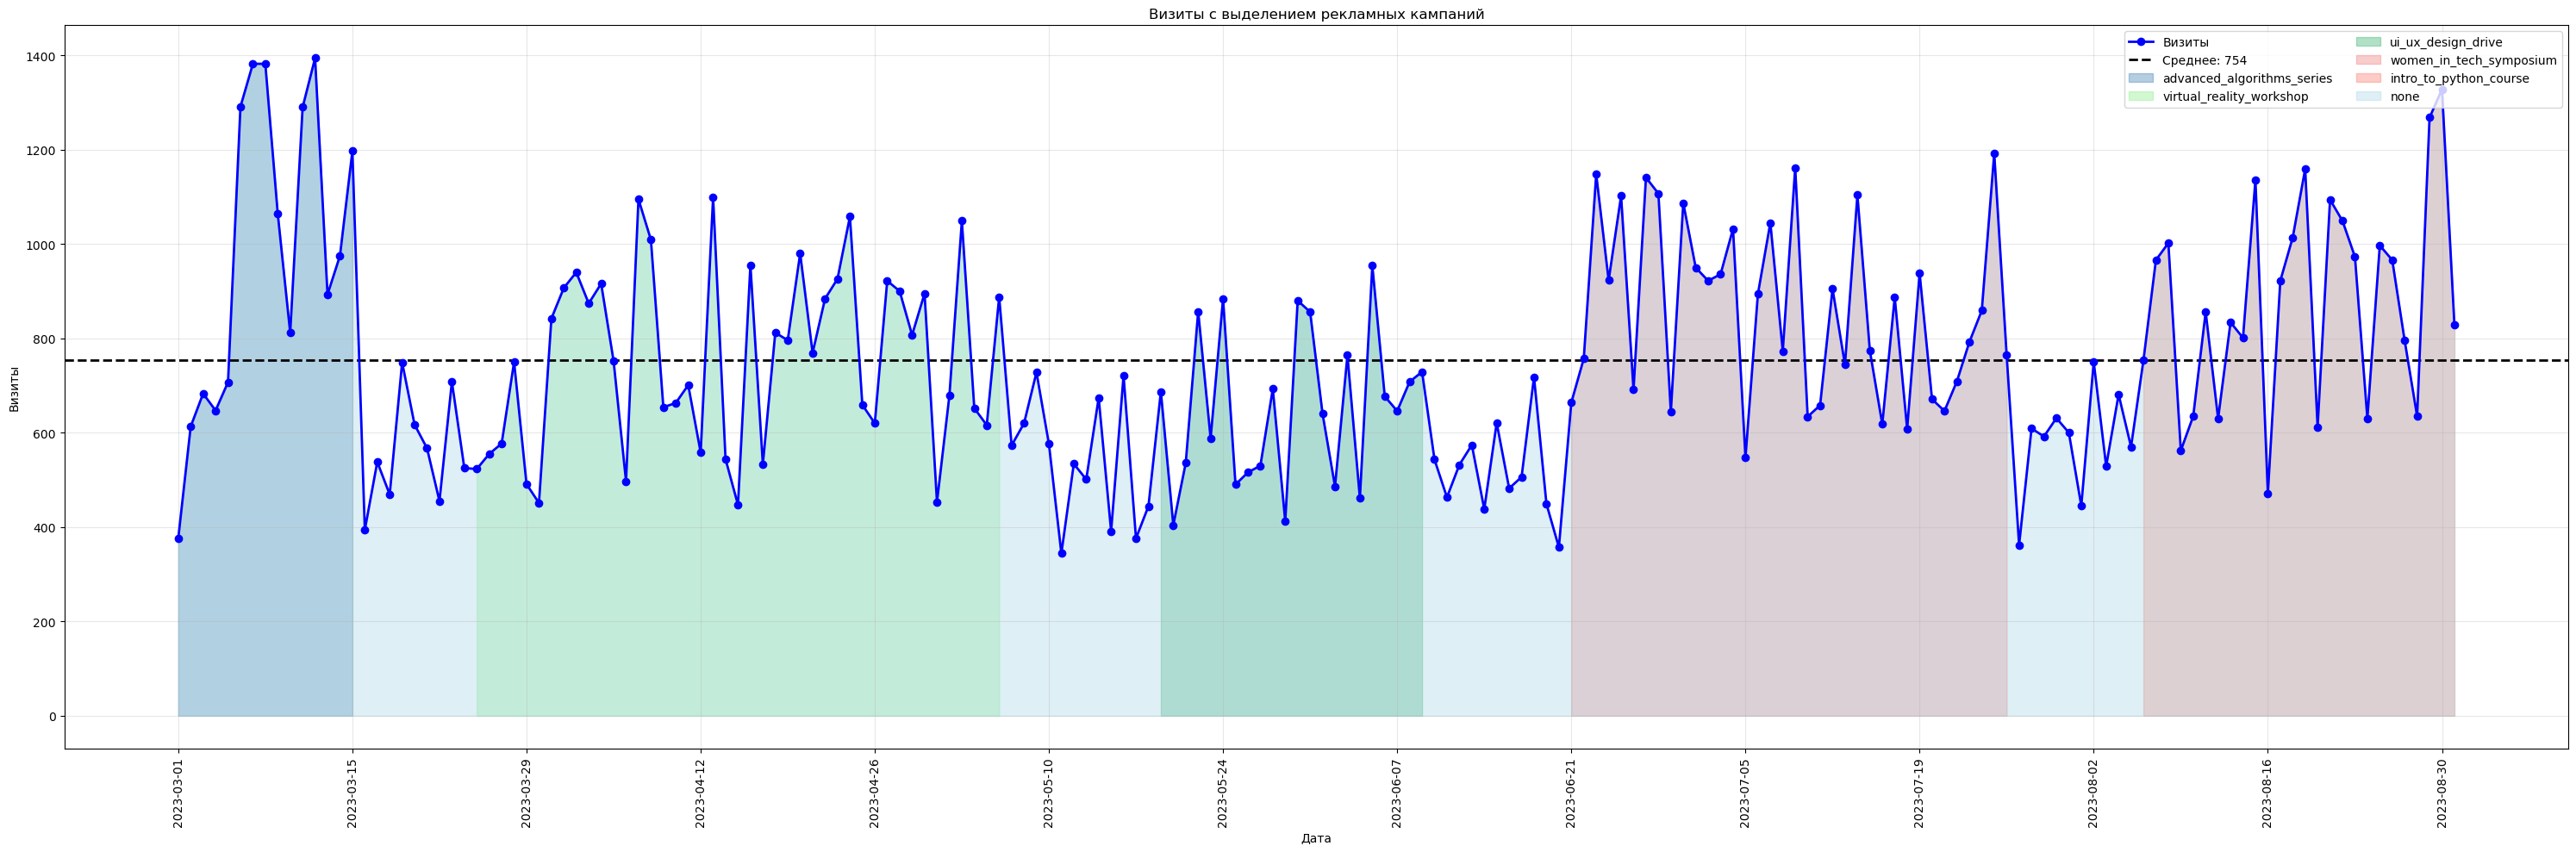

In [25]:
# Визиты с рекламными кампаниями
plt.figure(figsize=(30, 10))
plt.title('Визиты с выделением рекламных кампаний')
plt.plot(final_df['date_group'], final_df['visits'],
         marker='o', linewidth=2, color='blue',
         label='Визиты', zorder=3)
avg = final_df['visits'].mean()
plt.axhline(y=avg, color='black', linestyle='--',
            linewidth=2, label=f'Среднее: {avg:.0f}')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.xticks(final_df['date_group'][::14], rotation=90)
plt.grid(True, alpha=0.3)
ads_df['date'] = pd.to_datetime(ads_df['date']).dt.normalize()

campaign_colors = {
    'advanced_algorithms_series': 'steelblue',
    'virtual_reality_workshop': 'lightgreen',
    'ui_ux_design_drive': 'mediumseagreen',
    'women_in_tech_symposium': 'lightcoral',
    'intro_to_python_course': 'salmon'
}

for campaign in ads_df['utm_campaign'].unique():
    camp_dates = ads_df[ads_df['utm_campaign'] == campaign]['date'].unique()

    mask = final_df['date_group'].isin(camp_dates)
    plt.fill_between(final_df['date_group'], 0, final_df['visits'],
                     where=mask,
                     color=campaign_colors.get(campaign, 'gray'),
                     alpha=0.4, label=campaign)

no_ads = final_df['cost'] == 0
plt.fill_between(final_df['date_group'], 0, final_df['visits'],
                 where=no_ads, color='lightblue',
                 alpha=0.4, label='none')

plt.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('./charts/visits_with_campaigns.png', dpi=300, bbox_inches='tight')
plt.show()

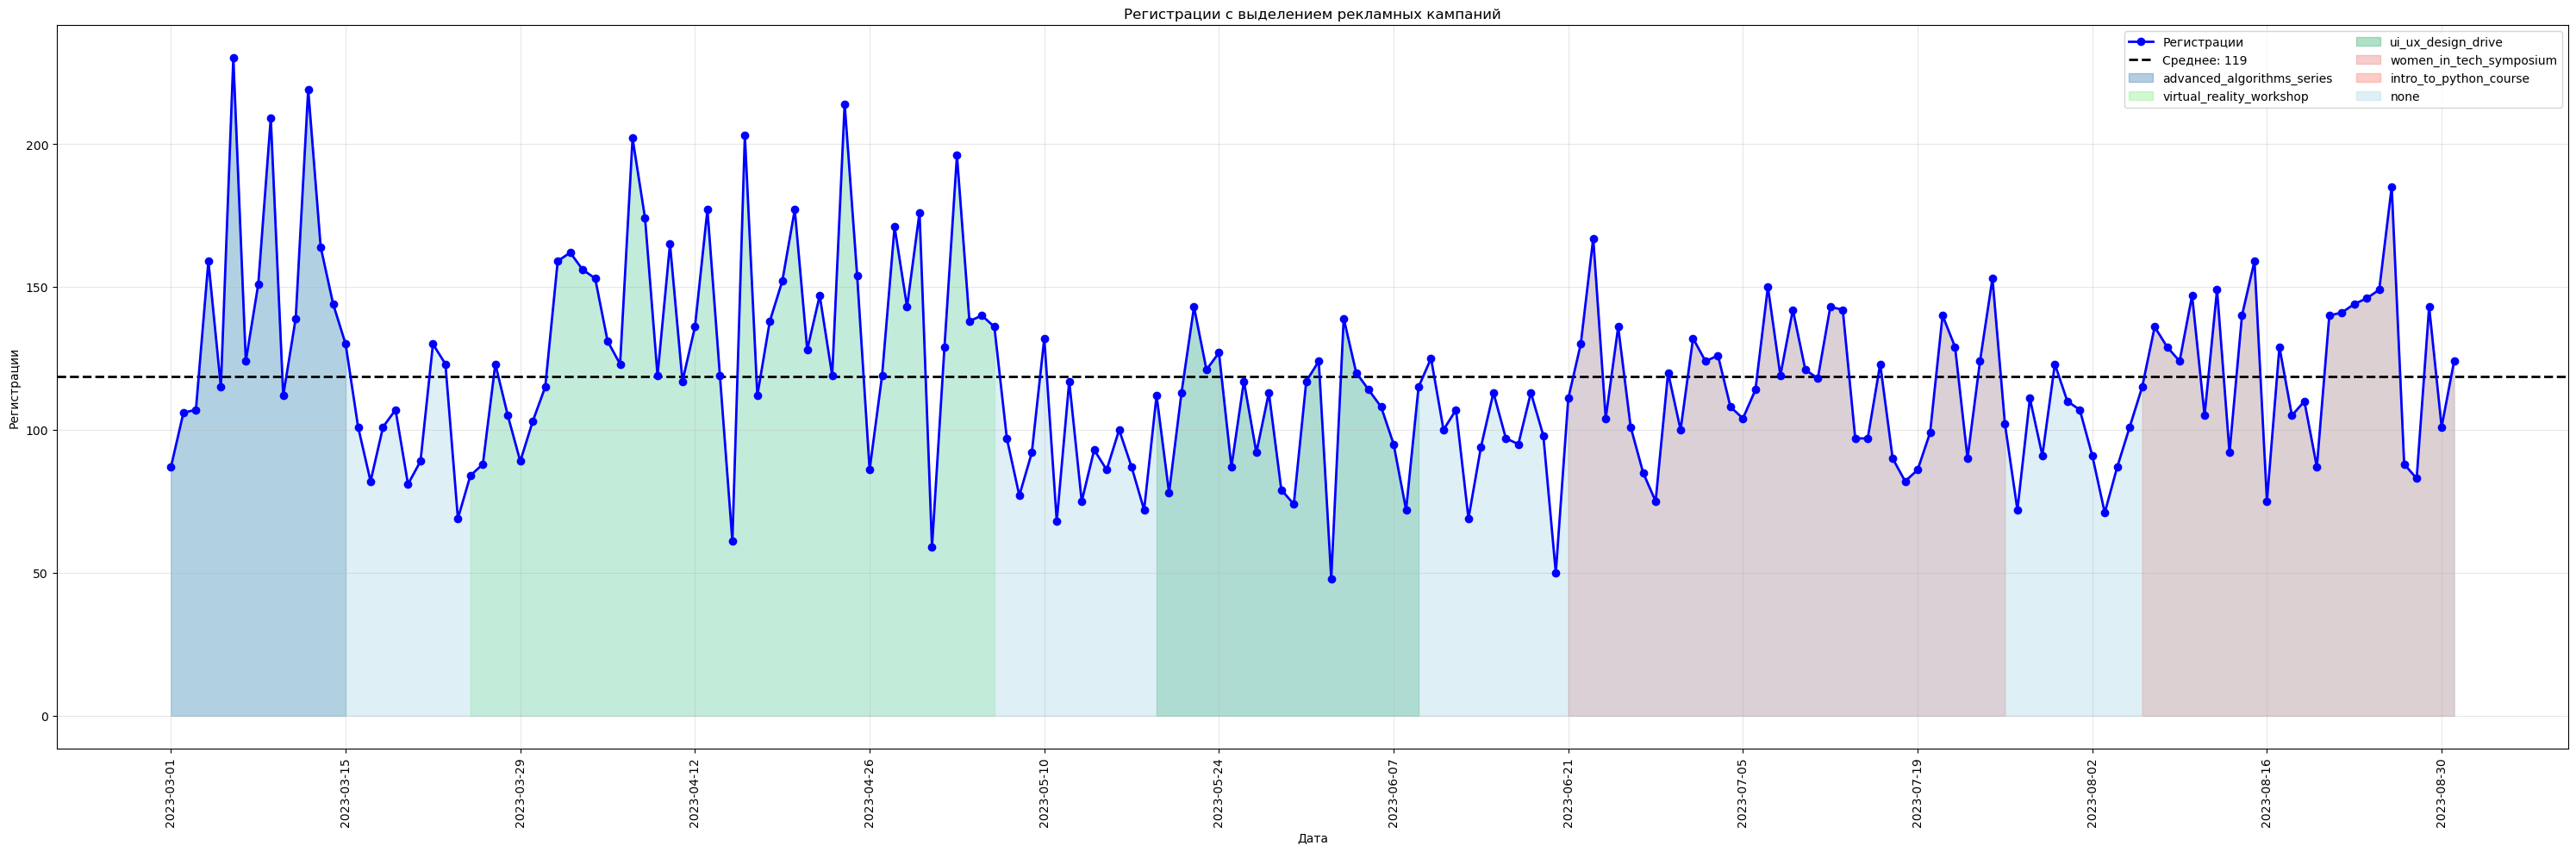

In [26]:
# Регистрации с рекламными кампаниями
plt.figure(figsize=(30, 10))
plt.title('Регистрации с выделением рекламных кампаний')
plt.plot(final_df['date_group'], final_df['registrations'],
         marker='o', linewidth=2, color='blue',
         label='Регистрации', zorder=3)

avg = final_df['registrations'].mean()
plt.axhline(y=avg, color='black', linestyle='--',
            linewidth=2, label=f'Среднее: {avg:.0f}')
plt.xlabel('Дата')
plt.ylabel('Регистрации')
plt.xticks(final_df['date_group'][::14], rotation=90)
plt.grid(True, alpha=0.3)
ads_df['date'] = pd.to_datetime(ads_df['date']).dt.normalize()

for campaign in ads_df['utm_campaign'].unique():
    camp_dates = ads_df[ads_df['utm_campaign'] == campaign]['date'].unique()
    mask = final_df['date_group'].isin(camp_dates)
    plt.fill_between(final_df['date_group'], 0, final_df['registrations'],
                     where=mask,
                     color=campaign_colors.get(campaign, 'gray'),
                     alpha=0.4, label=campaign)

no_ads = final_df['cost'] == 0
plt.fill_between(final_df['date_group'], 0, final_df['registrations'],
                 where=no_ads, color='lightblue',
                 alpha=0.4, label='none')
plt.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('./charts/registrations_with_campaigns.png', dpi=300, bbox_inches='tight')
plt.show()